<p align="center">
  <a href="https://vicena.ai"><strong>Built with Vicena</strong></a>
</p>

# Held-out validation and residual diagnostics

This notebook is part of the Vicena Research Twins collection. Purpose: evaluate the calibrated reference model on the untouched chronological validation period. Inputs use degC and interval kWh. Execution prints MAE, RMSE, CVRMSE, NMBE, residual quantiles, and lag-1 correlation, then plots observed and predicted temperature. Maturity: Level 0 synthetic reference. Limitation: synthetic held-out agreement is not measured building validation.

Validation metrics: {'indoor_temperature': {'n': 217, 'mae': 0.355346616091695, 'rmse': 0.442264546035537, 'bias': -0.12484757582453901, 'cvrmse_percent': 2.5246322682966618, 'nmbe_percent': -0.7126825366641956}, 'energy': {'n': 217, 'mae': 0.1792731679007773, 'rmse': 0.702123532905396, 'bias': -0.0033827451168778155, 'cvrmse_percent': 50.80870944272045, 'nmbe_percent': -0.24479013408226624}}
Residual diagnostics: {'temperature': {'mean': -0.12484757582453901, 'std': 0.4252580343782028, 'p05': -0.7340209513636005, 'p95': 0.7164955787120542, 'lag1_autocorrelation': 0.7901641297059571}, 'energy': {'mean': -0.0033827451168778155, 'std': 0.703738774370772, 'p05': -0.06632111234843992, 'p95': 0.4005553131070938, 'lag1_autocorrelation': 0.24256822036674547}}


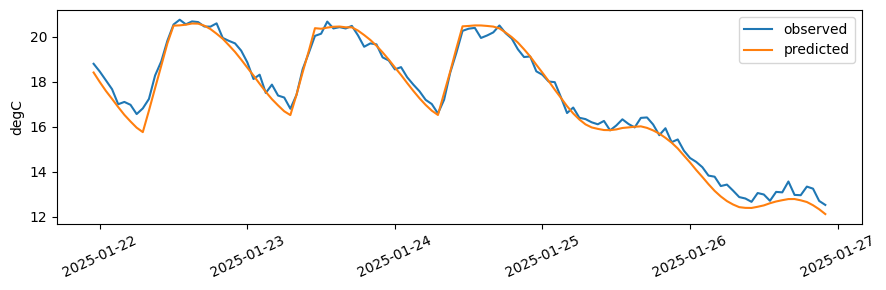

In [2]:
from building_hvac_twin.data import load_dataset, temporal_split
from building_hvac_twin.model import TwinParameters
from building_hvac_twin.analysis import calibrate,evaluate,residual_diagnostics
import matplotlib.pyplot as plt

data=load_dataset('../datasets/example/building_timeseries.csv'); train,val=temporal_split(data)
p,_=calibrate(train,TwinParameters()); sim,metrics=evaluate(val,p); diagnostics=residual_diagnostics(val,sim)
print('Validation metrics:',metrics); print('Residual diagnostics:',diagnostics)
plt.figure(figsize=(9,3)); plt.plot(val.timestamp.iloc[:120],val.indoor_temp_c.iloc[:120],label='observed'); plt.plot(val.timestamp.iloc[:120],sim.predicted_indoor_temp_c.iloc[:120],label='predicted'); plt.ylabel('degC'); plt.legend(); plt.xticks(rotation=25); plt.tight_layout(); plt.show()